(mmm_lfo_cv_model_comparison)=
# Fast MMM comparison with approximate leave-future-out cross-validation

When building a marketing mix model, we often face several defensible modeling choices.  Different assumptions about how advertising contributes to sales lead to different model structures: effects may combine additively on the sales scale, multiplicatively on the log-sales scale, or through a log-log relationship that changes the interpretation of media coefficients.  Prior assumptions can also matter, especially when channels are correlated or weakly identified.

Rather than choosing among these assumptions only by in-sample fit or convenience, we want to compare the models by their ability to predict future observations.  A straightforward rolling-origin evaluation would refit every candidate model at every forecast origin, but this can be expensive for Bayesian MMMs.

This case study demonstrates an efficient alternative: **leave-future-out cross-validation (LFO-CV)** with **Pareto-smoothed importance sampling (PSIS)**.  We fit each candidate for an initial time window, then use PSIS to update the posterior estimate as the forecast origin moves forward.  Whenever the Pareto-$k$ diagnostic indicates that the approximation is unreliable, we refit the model.  This makes a sliding-window model comparison feasible while retaining diagnostics for when the approximation breaks down.

We compare four alternative MMM structures over a one-week-ahead sliding forecast window:

| Model | Link | Saturation | Likelihood | Purpose |
|---|---|---|---|---|
| Additive | `identity` | `LogisticSaturation` | Normal | Standard additive MMM |
| Additive, tight priors | `identity` | `LogisticSaturation` | Normal | Prior-misspecification stress test |
| Log / multiplicative | `log` | `LogisticSaturation` | LogNormal | Multiplicative MMM |
| Log-log | `log` | `LogSaturation` | LogNormal | Multiplicative with log saturation |

For more detail on the additive, log, and log-log MMM parameterizations, see the {ref}`mmm_multiplicative`.

## Prepare notebook

The `arviz_stats.lfo_cv` API used here is currently newer than the released ArviZ umbrella package.  The compatibility shim below mirrors the exploratory notebook and should be removed once synchronized releases are available.

The LFO-CV API used below is currently available from the ArviZ development branch and is not in a released `arviz-stats` version yet. Until the synchronized release is available, run this notebook in an isolated environment and install the required `arviz-stats` revision manually:

```bash
uv pip install --no-deps "arviz-stats @ git+https://github.com/arviz-devs/arviz-stats@3d94eba58c1cfe0210f2d9dc49ec8b382eaa3046"
```

The notebook is temporarily excluded from CI execution until this dependency can be expressed as a normal project dependency.

In [2]:
import logging
import warnings

import arviz_base
import arviz_stats

# Temporary compatibility shim for the development LFO implementation.
# The development LFO API is shipped as arviz-stats 1.4.0.dev0, while the
# released ArviZ umbrella package checks that all ArviZ packages share a minor
# version. Match the local arviz-base version until synchronized releases exist.
if arviz_stats.__version__.startswith("1.4"):
    arviz_stats.__version__ = arviz_base.__version__

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy.special as sp
import xarray as xr
from arviz_stats import SamplingWrapper, compare, lfo_cv, weight_predictions
from pymc_extras.prior import Prior

from pymc_marketing.metrics import crps
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation, LogSaturation
from pymc_marketing.mmm.scaling import FixedScaling, Scaling

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("nutpie").setLevel(logging.ERROR)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

SOURCE_DATA_URL = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/mmm_example.csv"
SEED = sum(map(ord, "mmm_multiplicative_lfo_cv"))
rng = np.random.default_rng(SEED)

## Data and evaluation design

We use the synthetic weekly dataset from the multiplicative MMM example.  The target is strictly positive, which is required by the log-link models.

The key evaluation choices are:

- **Minimum training window**: the first 104 weeks.
- **Forecast horizon**: one week ahead.
- **Sliding origins**: every eligible week before the final holdout period.
- **Final holdout**: the last `HOLDOUT_WEEKS` observations are reserved for a transparent out-of-sample check after the LFO-CV comparison.
- **Fixed scaling**: scaling constants are computed from the initial training window and reused for every expanding-window refit.  This avoids leakage and keeps priors comparable across folds.

In [3]:
data = pd.read_csv(SOURCE_DATA_URL, parse_dates=["date_week"])
data = data.sort_values("date_week").reset_index(drop=True)

MIN_OBSERVATIONS = 104
HOLDOUT_WEEKS = 26
K_THRESHOLD = 0.7
FORECAST_HORIZON = 1
TREND_SCALE = MIN_OBSERVATIONS - 1

data["t"] = np.arange(len(data))
data["t_norm"] = data["t"] / TREND_SCALE

y = data["y"]
CHANNELS = ["x1", "x2"]
CONTROL_COLUMNS_ADDITIVE = ["event_1", "event_2", "t"]
CONTROL_COLUMNS_LOG = ["event_1", "event_2", "t_norm"]
DATE_COLUMN = "date_week"
TARGET_COLUMN = "y"

data[[DATE_COLUMN, TARGET_COLUMN, *CHANNELS, "event_1", "event_2"]].head()

,date_week,y,x1,x2,event_1,event_2
0,2018-04-02,3984.662237,0.318580,0.0,0.0,0.0
1,2018-04-09,3762.871794,0.112388,0.0,0.0,0.0
2,2018-04-16,4466.967388,0.292400,0.0,0.0,0.0
3,2018-04-23,3864.219373,0.071399,0.0,0.0,0.0
4,2018-04-30,4441.625278,0.386745,0.0,0.0,0.0


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Spend'), Text(0.5, 1.0, 'Channel x2')]

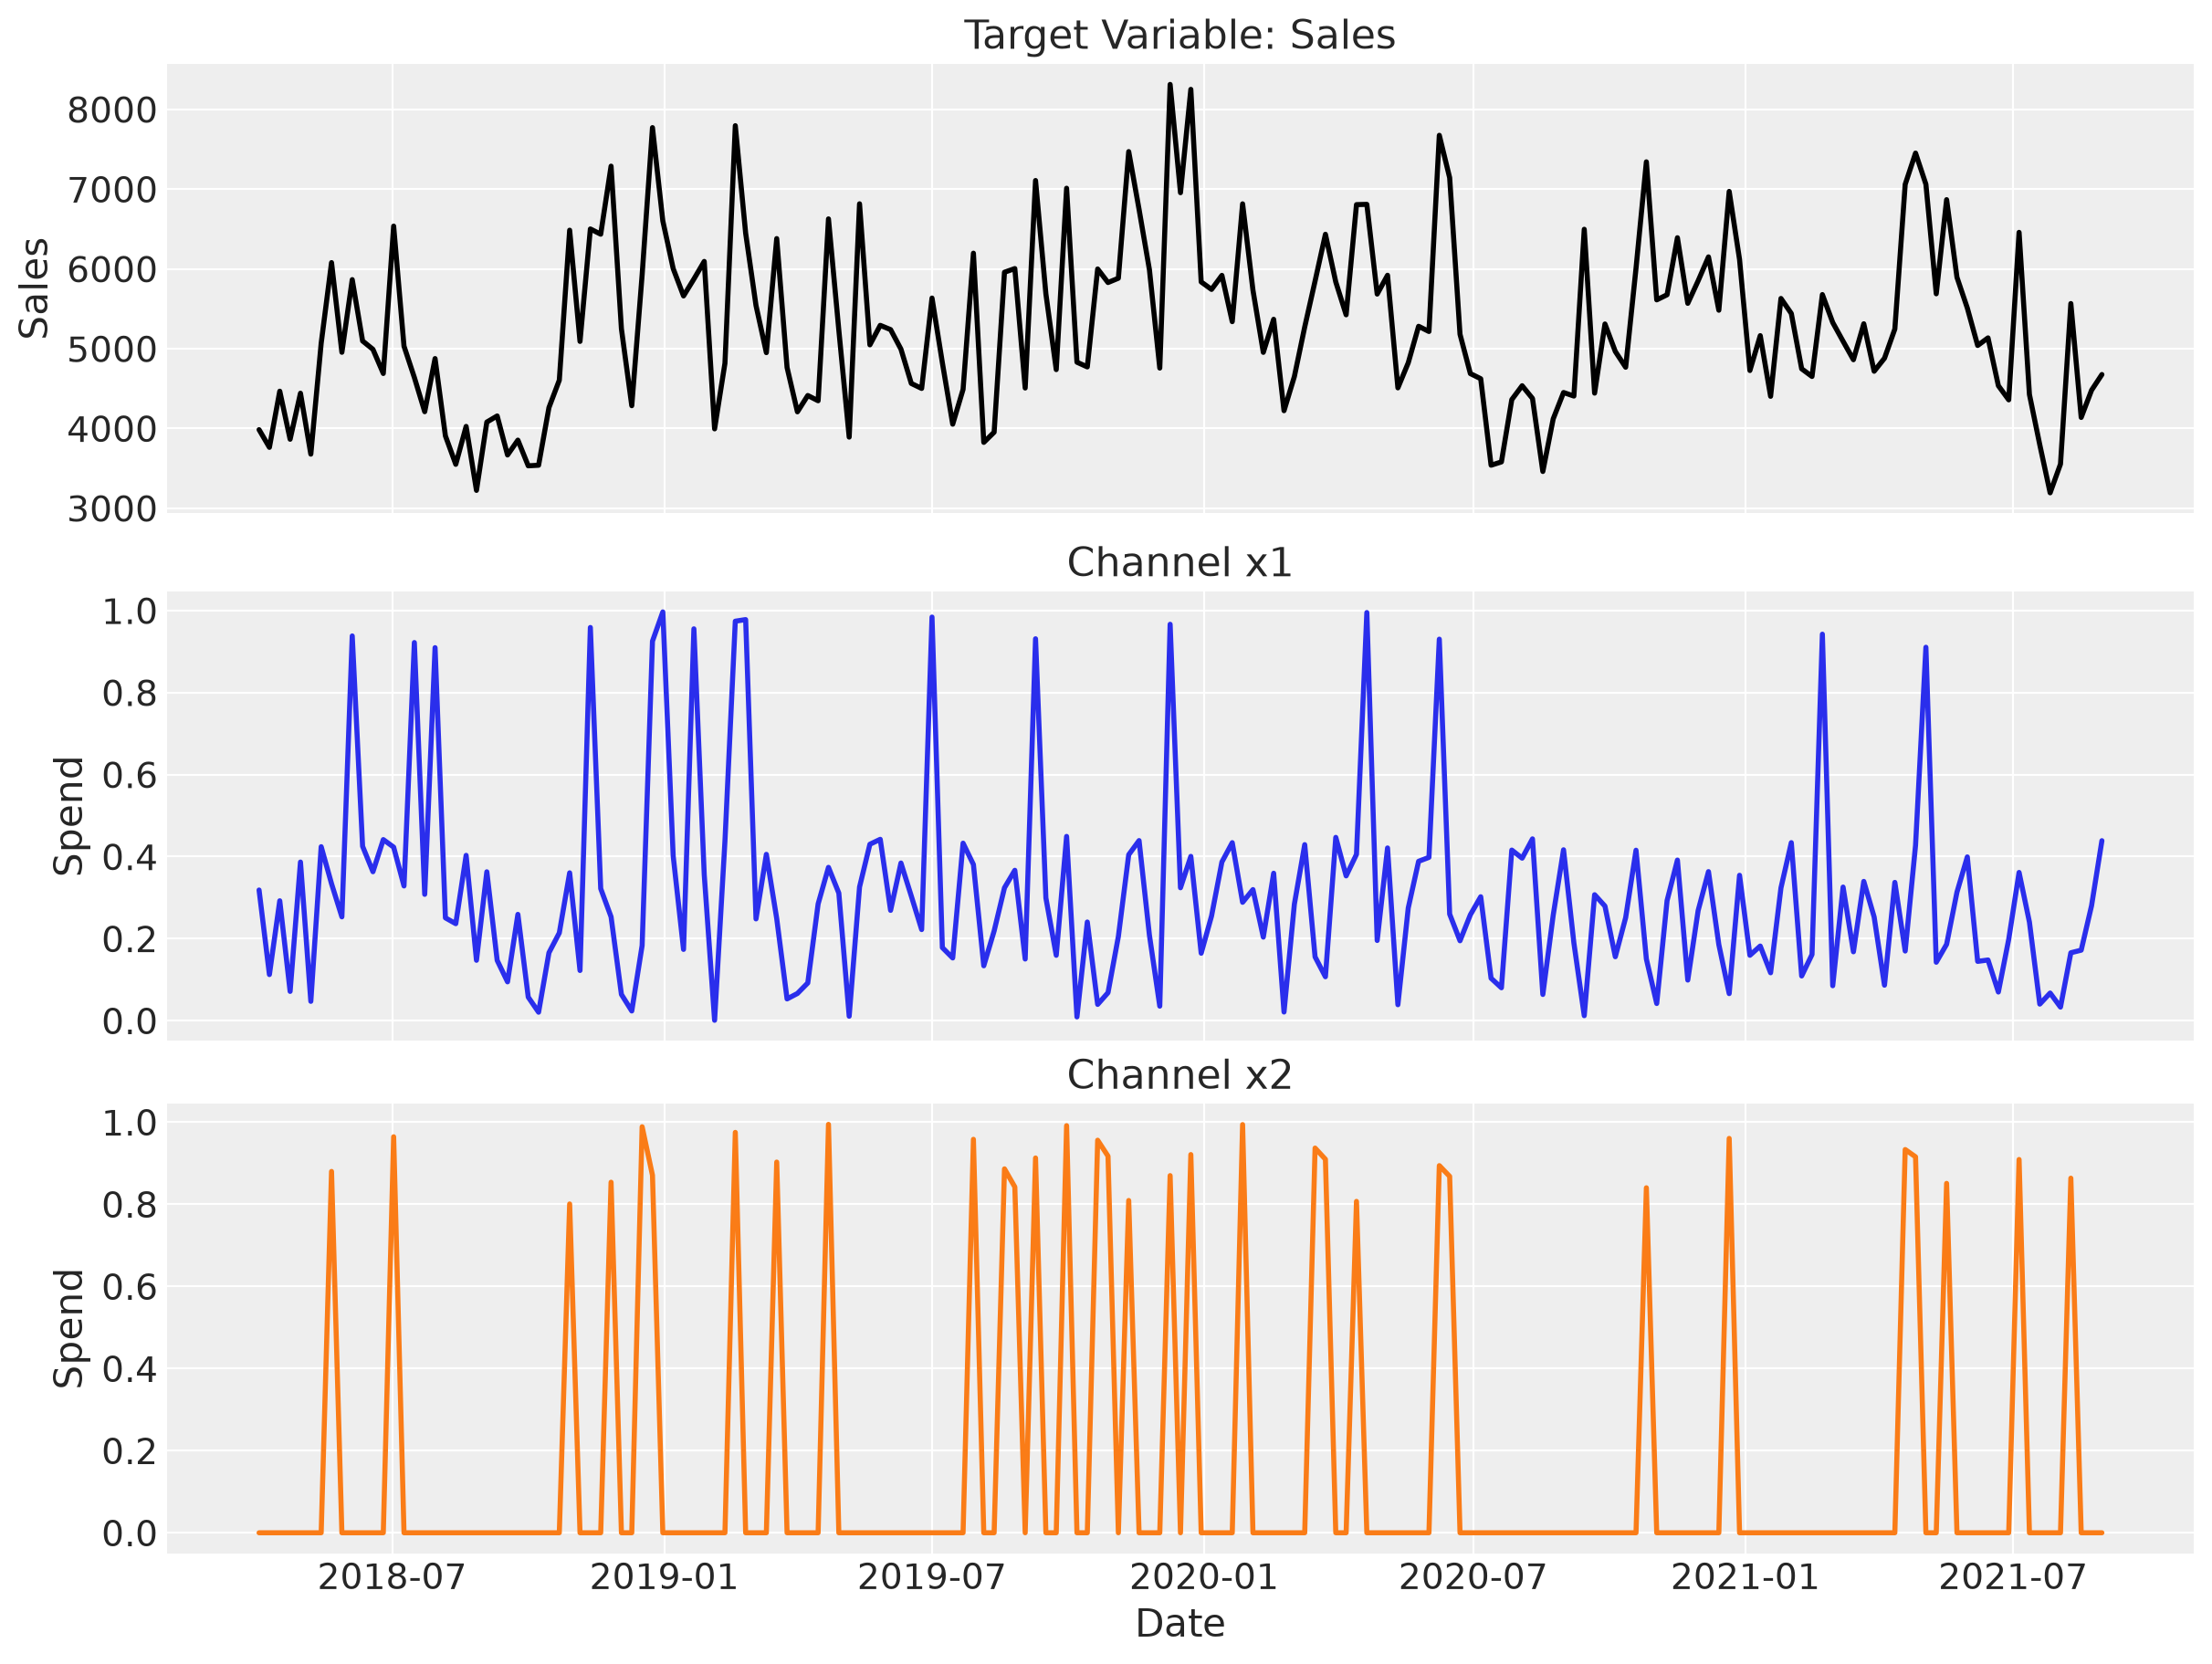

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Sales
axes[0].plot(data["date_week"], data["y"], color="black", linewidth=2)
axes[0].set(ylabel="Sales", title="Target Variable: Sales")

# Channel 1
axes[1].plot(data["date_week"], data["x1"], color="C0", linewidth=2)
axes[1].set(ylabel="Spend", title="Channel x1")

# Channel 2
axes[2].plot(data["date_week"], data["x2"], color="C1", linewidth=2)
axes[2].set(xlabel="Date", ylabel="Spend", title="Channel x2")

In [5]:
initial_data = data.iloc[:MIN_OBSERVATIONS]
fixed_target_scale = float(initial_data[TARGET_COLUMN].max())
fixed_channel_scales = {
    channel: float(initial_data[channel].max()) for channel in CHANNELS
}
fixed_scaling = Scaling(
    target=FixedScaling(dims=(), value=fixed_target_scale),
    channel=FixedScaling(dims=(), value=fixed_channel_scales),
)

scale_table = pd.DataFrame(
    {
        "variable": ["target", *CHANNELS],
        "fixed_scale": [fixed_target_scale, *fixed_channel_scales.values()],
        "source_rows": [f"0:{MIN_OBSERVATIONS}"] * (len(CHANNELS) + 1),
    }
)
scale_table

,variable,fixed_scale,source_rows
0,target,8312.407544,0:104
1,x1,0.996658,0:104
2,x2,0.994374,0:104


## Candidate MMM specifications

The models share the same target, media channels, adstock family, seasonality order, and fixed scaling. They differ in link function, saturation function, likelihood, priors, and trend parameterization. These differences encode alternative assumptions about how media effects and baseline dynamics enter the sales equation, not just alternative software settings.

The tight-prior additive model is included as a stress test: it is useful for showing that LFO-CV can penalize an implausibly rigid model, but it is not recommended as a production prior choice.

In [6]:
total_spend = initial_data[CHANNELS].sum()
spend_share = total_spend / total_spend.sum()
prior_sigma = len(CHANNELS) * spend_share.to_numpy()

additive_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.5), dims="date"),
}

additive_tight_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.02),
    "saturation_beta": Prior("HalfNormal", sigma=0.05 * prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.005, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.01, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.5), dims="date"),
}

log_model_config = {
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
}


def make_mmm(model_name: str) -> MMM:
    common_kwargs = dict(
        target_column=TARGET_COLUMN,
        date_column=DATE_COLUMN,
        channel_columns=CHANNELS,
        yearly_seasonality=2,
        adstock=GeometricAdstock(l_max=8),
        scaling=fixed_scaling,
    )
    match model_name:
        case "additive":
            return MMM(
                model_config=additive_model_config,
                control_columns=CONTROL_COLUMNS_ADDITIVE,
                saturation=LogisticSaturation(),
                link="identity",
                **common_kwargs,
            )
        case "additive_tight":
            return MMM(
                model_config=additive_tight_model_config,
                control_columns=CONTROL_COLUMNS_ADDITIVE,
                saturation=LogisticSaturation(),
                link="identity",
                **common_kwargs,
            )
        case "log":
            return MMM(
                model_config=log_model_config,
                control_columns=CONTROL_COLUMNS_LOG,
                saturation=LogisticSaturation(),
                link="log",
                **common_kwargs,
            )
        case "loglog":
            return MMM(
                model_config=log_model_config,
                control_columns=CONTROL_COLUMNS_LOG,
                saturation=LogSaturation(),
                link="log",
                **common_kwargs,
            )
        case _:
            raise ValueError(f"Unknown model name: {model_name}")


MODEL_NAMES = ["additive", "additive_tight", "log", "loglog"]
MODEL_LABELS = {
    "additive": "Additive (identity)",
    "additive_tight": "Additive (tight priors)",
    "log": "Log (multiplicative)",
    "loglog": "Log-log",
}

## LFO wrapper for PyMC-Marketing

`arviz_stats.lfo_cv` is model-agnostic: it only needs a small interface that says how to refit a model for a set of observations and how to score future observations under the refitted posterior.  PyMC-Marketing's `MMM` class already knows how to build, fit, and predict, but it does not expose that exact LFO-CV interface directly.

The wrapper below is the adapter between the two APIs.  For each requested forecast origin it:

1. selects the expanding training prefix and the future observation to score,
2. rebuilds the same MMM specification with the fixed scaling constants,
3. exposes a `sample` method that `lfo_cv` calls when PSIS diagnostics require an exact refit, and
4. computes the held-out log likelihood on the forecast week while preserving adstock history.

This is the main technical bridge in the notebook: the statistical comparison is generic LFO-CV, while the model fitting and data transformations remain ordinary PyMC-Marketing MMM operations.

In [7]:
class PyMCMarketingLfoWrapper(SamplingWrapper):
    """Refit a PyMC-Marketing MMM on a prefix and score future observations."""

    def __init__(self, model_name: str, fit_kwargs: dict, source_data: pd.DataFrame):
        """Store the model name, fit configuration, and full pre-holdout data."""
        super().__init__(model=None, idata_orig=None)
        self.model_name = model_name
        self.fit_kwargs = dict(fit_kwargs)
        self.source_data = source_data.sort_values(DATE_COLUMN).reset_index(drop=True)
        self.n_time = len(self.source_data)
        self.current_cutoff = None
        self.current_mmm = None
        self.fit_count = 0
        self.refit_rows = []

    def sel_observations(self, idx):
        """Return the expanding training prefix and excluded future rows."""
        idx = np.atleast_1d(idx).astype(int)
        self.current_cutoff = int(idx.min())
        train = self.source_data.iloc[: self.current_cutoff].copy()
        excluded = self.source_data.iloc[idx].copy()
        return train, excluded

    def sample(self, modified_observed_data):
        """Fit the candidate MMM on the supplied training prefix."""
        self.fit_count += 1
        mmm_i = make_mmm(self.model_name)
        x_train = modified_observed_data.drop(columns=[TARGET_COLUMN])
        y_train = modified_observed_data[TARGET_COLUMN]
        idata_i = mmm_i.fit(X=x_train, y=y_train, **self.fit_kwargs)

        actual_target_scale = float(idata_i["constant_data"]["target_scale"])
        actual_channel_scale = idata_i["constant_data"]["channel_scale"]
        if not np.isclose(actual_target_scale, fixed_target_scale):
            raise ValueError(f"Unexpected target scale for {self.model_name}.")
        expected_channel_scale = (
            xr.ones_like(actual_channel_scale)
            if self.model_name == "loglog"
            else xr.DataArray(
                [fixed_channel_scales[channel] for channel in CHANNELS],
                dims=["channel"],
                coords={"channel": CHANNELS},
            )
        )
        if not np.allclose(actual_channel_scale, expected_channel_scale):
            raise ValueError(f"Unexpected channel scale for {self.model_name}.")

        self.current_mmm = mmm_i
        forecast_date = (
            self.source_data[DATE_COLUMN].iloc[self.current_cutoff]
            if self.current_cutoff is not None and self.current_cutoff < self.n_time
            else pd.NaT
        )
        self.refit_rows.append(
            {
                "model": self.model_name,
                "fit_count": self.fit_count,
                "cutoff": self.current_cutoff,
                "n_train": len(modified_observed_data),
                "fit_date": modified_observed_data[DATE_COLUMN].iloc[-1],
                "forecast_date": forecast_date,
                "target_scale": actual_target_scale,
                "channel_scale_x1": float(actual_channel_scale.sel(channel="x1")),
                "channel_scale_x2": float(actual_channel_scale.sel(channel="x2")),
            }
        )
        return mmm_i

    def get_inference_data(self, fitted_model):
        """Return the fitted model's DataTree."""
        return fitted_model.idata

    def log_likelihood__i(self, excluded_obs, idata__i):
        """Compute log likelihood for the excluded forecast rows."""
        mmm_i = self.current_mmm
        x_excluded = excluded_obs.drop(columns=[TARGET_COLUMN])
        y_excluded = excluded_obs[TARGET_COLUMN]
        dataset_xarray = mmm_i._posterior_predictive_data_transformation(
            X=x_excluded,
            y=y_excluded,
            include_last_observations=True,
        )
        model = mmm_i.model.copy()
        model = mmm_i._set_xarray_data(dataset_xarray=dataset_xarray, model=model)
        for mu_effect in mmm_i.mu_effects:
            mu_effect.set_data(mmm_i, model, dataset_xarray)

        idata_for_ll = idata__i.copy()
        if "log_likelihood" in idata_for_ll:
            del idata_for_ll["log_likelihood"]
        pm.compute_log_likelihood(
            idata_for_ll,
            var_names=[mmm_i.output_var],
            model=model,
            progressbar=False,
        )
        log_lik = idata_for_ll["log_likelihood"][mmm_i.output_var]
        log_lik = log_lik.isel(date=slice(-len(excluded_obs), None))
        log_lik = log_lik.assign_coords(
            date=np.asarray(excluded_obs[DATE_COLUMN].values)
        )
        return log_lik

## Run approximate LFO-CV

We now fit all candidate models and evaluate the one-week-ahead sliding forecast window.

The first fit for each model is restricted to the pre-holdout data.  LFO-CV then scores every eligible pre-holdout origin, using PSIS where possible and exact refits when `pareto_k > K_THRESHOLD`.  The pointwise ELPD values are the log predictive scores for each forecast origin.

In [8]:
%%capture
fit_kwargs = {
    "chains": 4,
    "target_accept": 0.9,
    "draws": 2000,
    "tune": 1000,
    "nuts_sampler": "nutpie",
    "random_seed": int(rng.integers(1, 2**30)),
    "progressbar": False,
}


def fit_reference_model(model_name: str, fit_data: pd.DataFrame):
    mmm = make_mmm(model_name)
    x_fit = fit_data.drop(columns=[TARGET_COLUMN])
    y_fit = fit_data[TARGET_COLUMN]
    idata = mmm.fit(X=x_fit, y=y_fit, **fit_kwargs)
    pm.compute_log_likelihood(
        idata,
        var_names=[mmm.output_var],
        model=mmm.model,
        progressbar=False,
    )
    return mmm, idata


def run_one_lfo(model_name: str, fit_data: pd.DataFrame):
    reference_mmm, reference_idata = fit_reference_model(model_name, fit_data)
    wrapper = PyMCMarketingLfoWrapper(
        model_name,
        fit_kwargs=fit_kwargs,
        source_data=fit_data,
    )
    result = lfo_cv(
        reference_idata,
        wrapper=wrapper,
        min_observations=MIN_OBSERVATIONS,
        forecast_horizon=FORECAST_HORIZON,
        time_dim="date",
        var_name=reference_mmm.output_var,
        method="approx",
        k_threshold=K_THRESHOLD,
        pointwise=True,
    )
    return result, wrapper, reference_mmm


lfo_cutoff = len(data) - HOLDOUT_WEEKS
if lfo_cutoff <= MIN_OBSERVATIONS:
    raise ValueError("The holdout leaves too few observations for LFO-CV")
lfo_data = data.iloc[:lfo_cutoff].copy()

lfo_runs = {}
for model_name in MODEL_NAMES:
    lfo_runs[model_name] = run_one_lfo(model_name, lfo_data)

lfo_results = {name: run[0] for name, run in lfo_runs.items()}
lfo_wrappers = {name: run[1] for name, run in lfo_runs.items()}
reference_mmm_by_model = {name: run[2] for name, run in lfo_runs.items()}

In [9]:
lfo_summary = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[name],
            "ELPD_LFO": result.elpd,
            "SE": result.se,
            "origins": result.n_data_points,
            "PSIS_refits": result.n_refits,
            "warning": result.warning,
        }
        for name, result in lfo_results.items()
    ]
).sort_values("ELPD_LFO", ascending=False)
lfo_summary

,model,ELPD_LFO,SE,origins,PSIS_refits,warning
2,Log (multiplicative),94.058624,5.336998,49,1,False
3,Log-log,85.791079,5.772988,49,1,False
0,Additive (identity),82.361687,18.906040,49,2,False
1,Additive (tight priors),65.784202,21.583902,49,2,False


## Compare models with pointwise ELPD

First, we use the LFO-CV results for ordinary model comparison: which single model has the best expected one-week-ahead predictive performance?  The table ranks models by expected log predictive density (ELPD).  Higher ELPD is better, and the paired standard errors help distinguish meaningful differences from noise.

```{note}
**What is ELPD?** Expected log predictive density is the average log probability that a model assigns to future observations.  In this notebook each pointwise contribution is the log predictive density for one held-out forecast week.  Higher values mean the model placed more probability mass near what actually happened.

ELPD is on a log-score scale, so differences are most useful in comparison: a model with larger ELPD has better estimated predictive accuracy for the evaluation task.  The standard errors reported below are paired across the same forecast origins, which helps quantify whether an apparent ranking difference is large relative to its uncertainty.
```

In [10]:
lfo_comparison = compare(lfo_results, method="stacking", round_to="none")
ranking_columns = [
    "rank",
    "elpd",
    "se",
    "elpd_diff",
    "dse",
    "p_worse",
    "diag_elpd",
    "weight",
]
lfo_comparison.sort_values(by="rank")[ranking_columns].round(3)

,rank,elpd,se,elpd_diff,dse,p_worse,diag_elpd,weight
log,0,94.059,5.337,0.000,0.000,NaN,,0.364
loglog,1,85.791,5.773,-8.268,2.714,0.999,,0.000
additive,2,82.362,18.906,-11.697,16.029,0.767,,0.636
additive_tight,3,65.784,21.584,-28.274,19.107,0.931,,0.000


## Stacking predictive distributions

Model ranking answers one question: *which single model would we choose if we had to pick exactly one?* Stacking answers a different question: *can a weighted mixture of the candidate predictive distributions forecast better than any single model?*

This is useful in MMM because alternative structural assumptions can capture different aspects of the data. For example, an additive model and a log-link model may make different errors at different forecast origins. Stacking uses the pre-holdout LFO scores to estimate weights for a predictive mixture, allowing the ensemble to keep complementary information from multiple plausible models instead of making an all-or-nothing selection.

An important feature of stacking is that the model with the largest stacking weight does not have to be the model with the best ELPD rank. This is not a contradiction. Stacking rewards models that add complementary predictive information to the ensemble. A model can rank lower on its own but still improve the mixture because it makes different errors than the top-ranked model. Similarly, a high-ranked model can receive little weight if its predictions are mostly redundant with a better model.

In [11]:
stacking_columns = ["rank", "elpd", "se", "elpd_diff", "dse", "weight"]
lfo_comparison.sort_values(by="weight", ascending=False)[stacking_columns].round(3)

,rank,elpd,se,elpd_diff,dse,weight
additive,2,82.362,18.906,-11.697,16.029,0.636
log,0,94.059,5.337,0.000,0.000,0.364
loglog,1,85.791,5.773,-8.268,2.714,0.000
additive_tight,3,65.784,21.584,-28.274,19.107,0.000


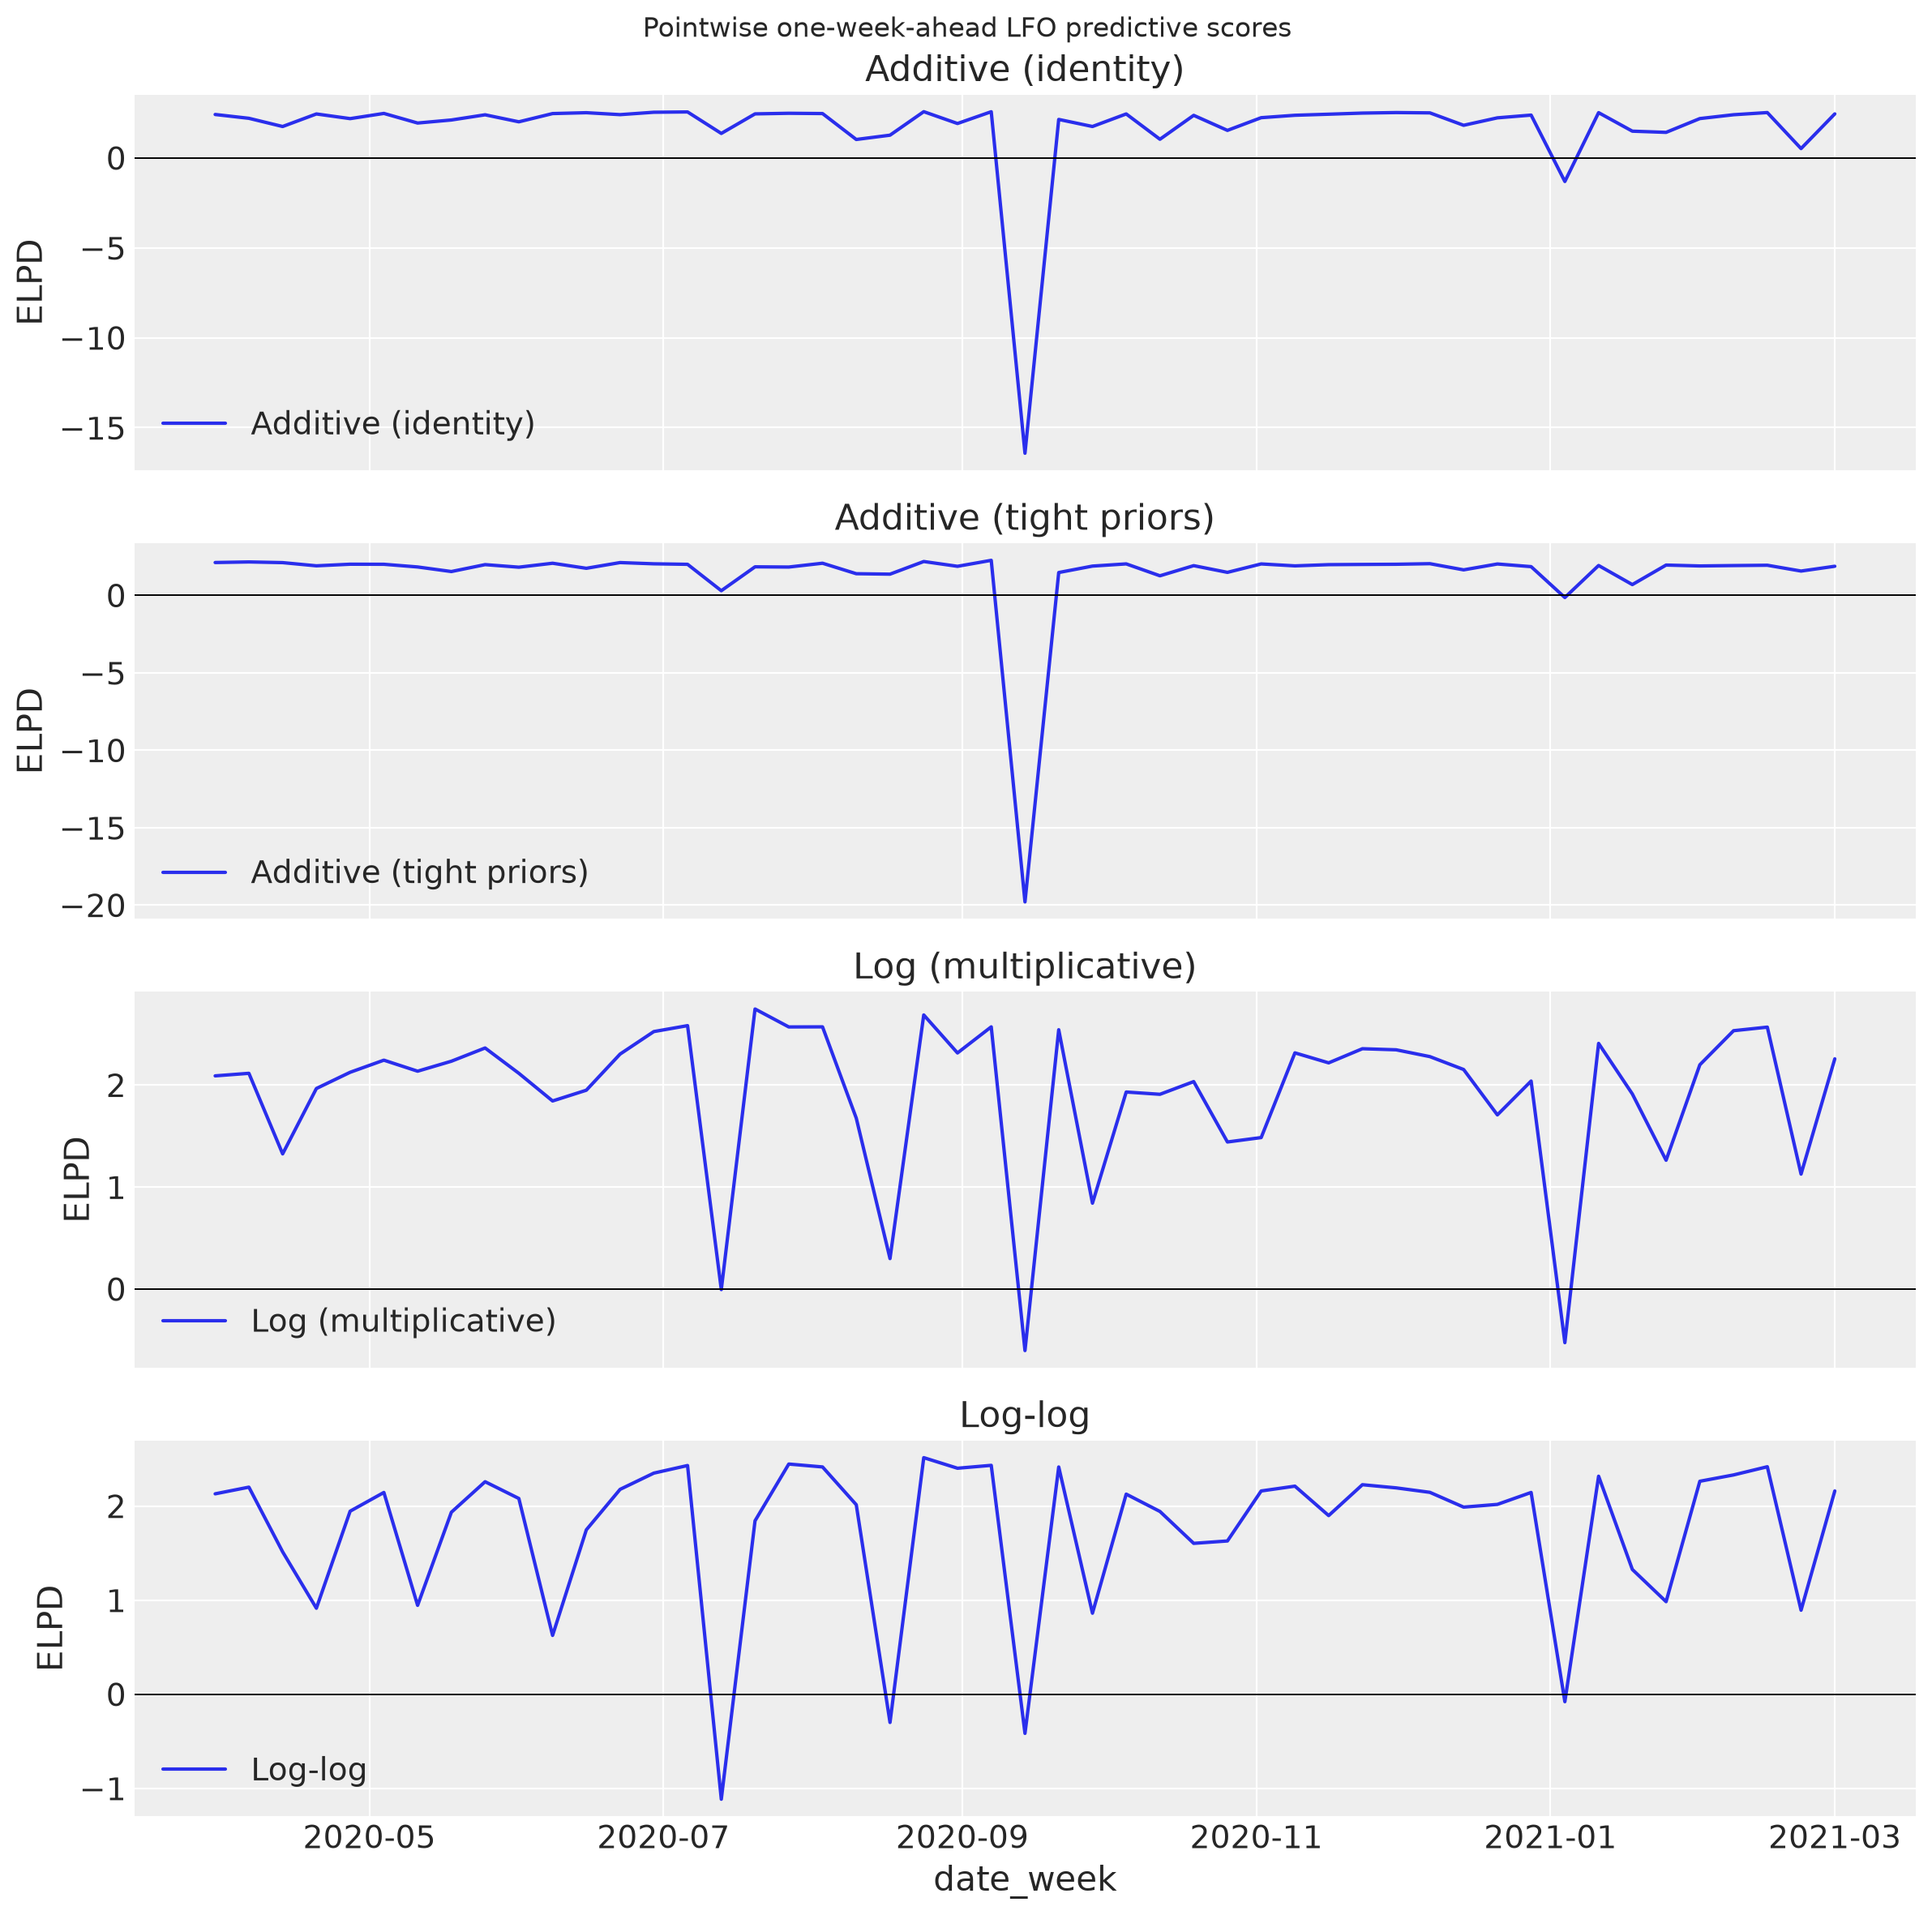

In [12]:
if lfo_results:
    fig, axes = plt.subplots(
        len(lfo_results), 1, figsize=(12, 3 * len(lfo_results)), sharex=True
    )
    axes = np.atleast_1d(axes)
    first_name = next(iter(lfo_results))
    dates = lfo_results[first_name].elpd_i.coords["date"].values
    for axis, (name, result) in zip(axes, lfo_results.items(), strict=True):
        axis.plot(dates, result.elpd_i.values, label=MODEL_LABELS[name])
        axis.axhline(0, color="black", linewidth=0.7)
        axis.set_ylabel("ELPD")
        axis.set_title(MODEL_LABELS[name])
        axis.legend()
    axes[-1].set_xlabel(DATE_COLUMN)
    fig.suptitle("Pointwise one-week-ahead LFO predictive scores")
    fig.tight_layout()

## PSIS diagnostics and refits

Approximate LFO-CV is efficient because it reuses posterior draws with PSIS weights until the approximation becomes unreliable. The Pareto-$k$ diagnostic tracks that reliability at each forecast origin. Values above the threshold trigger an exact refit, after which the diagnostic is reset for subsequent origins.

The plot below shows where the approximation was reliable and where exact refits were needed. This is the main diagnostic that makes PSIS-LFO more than a black-box shortcut.

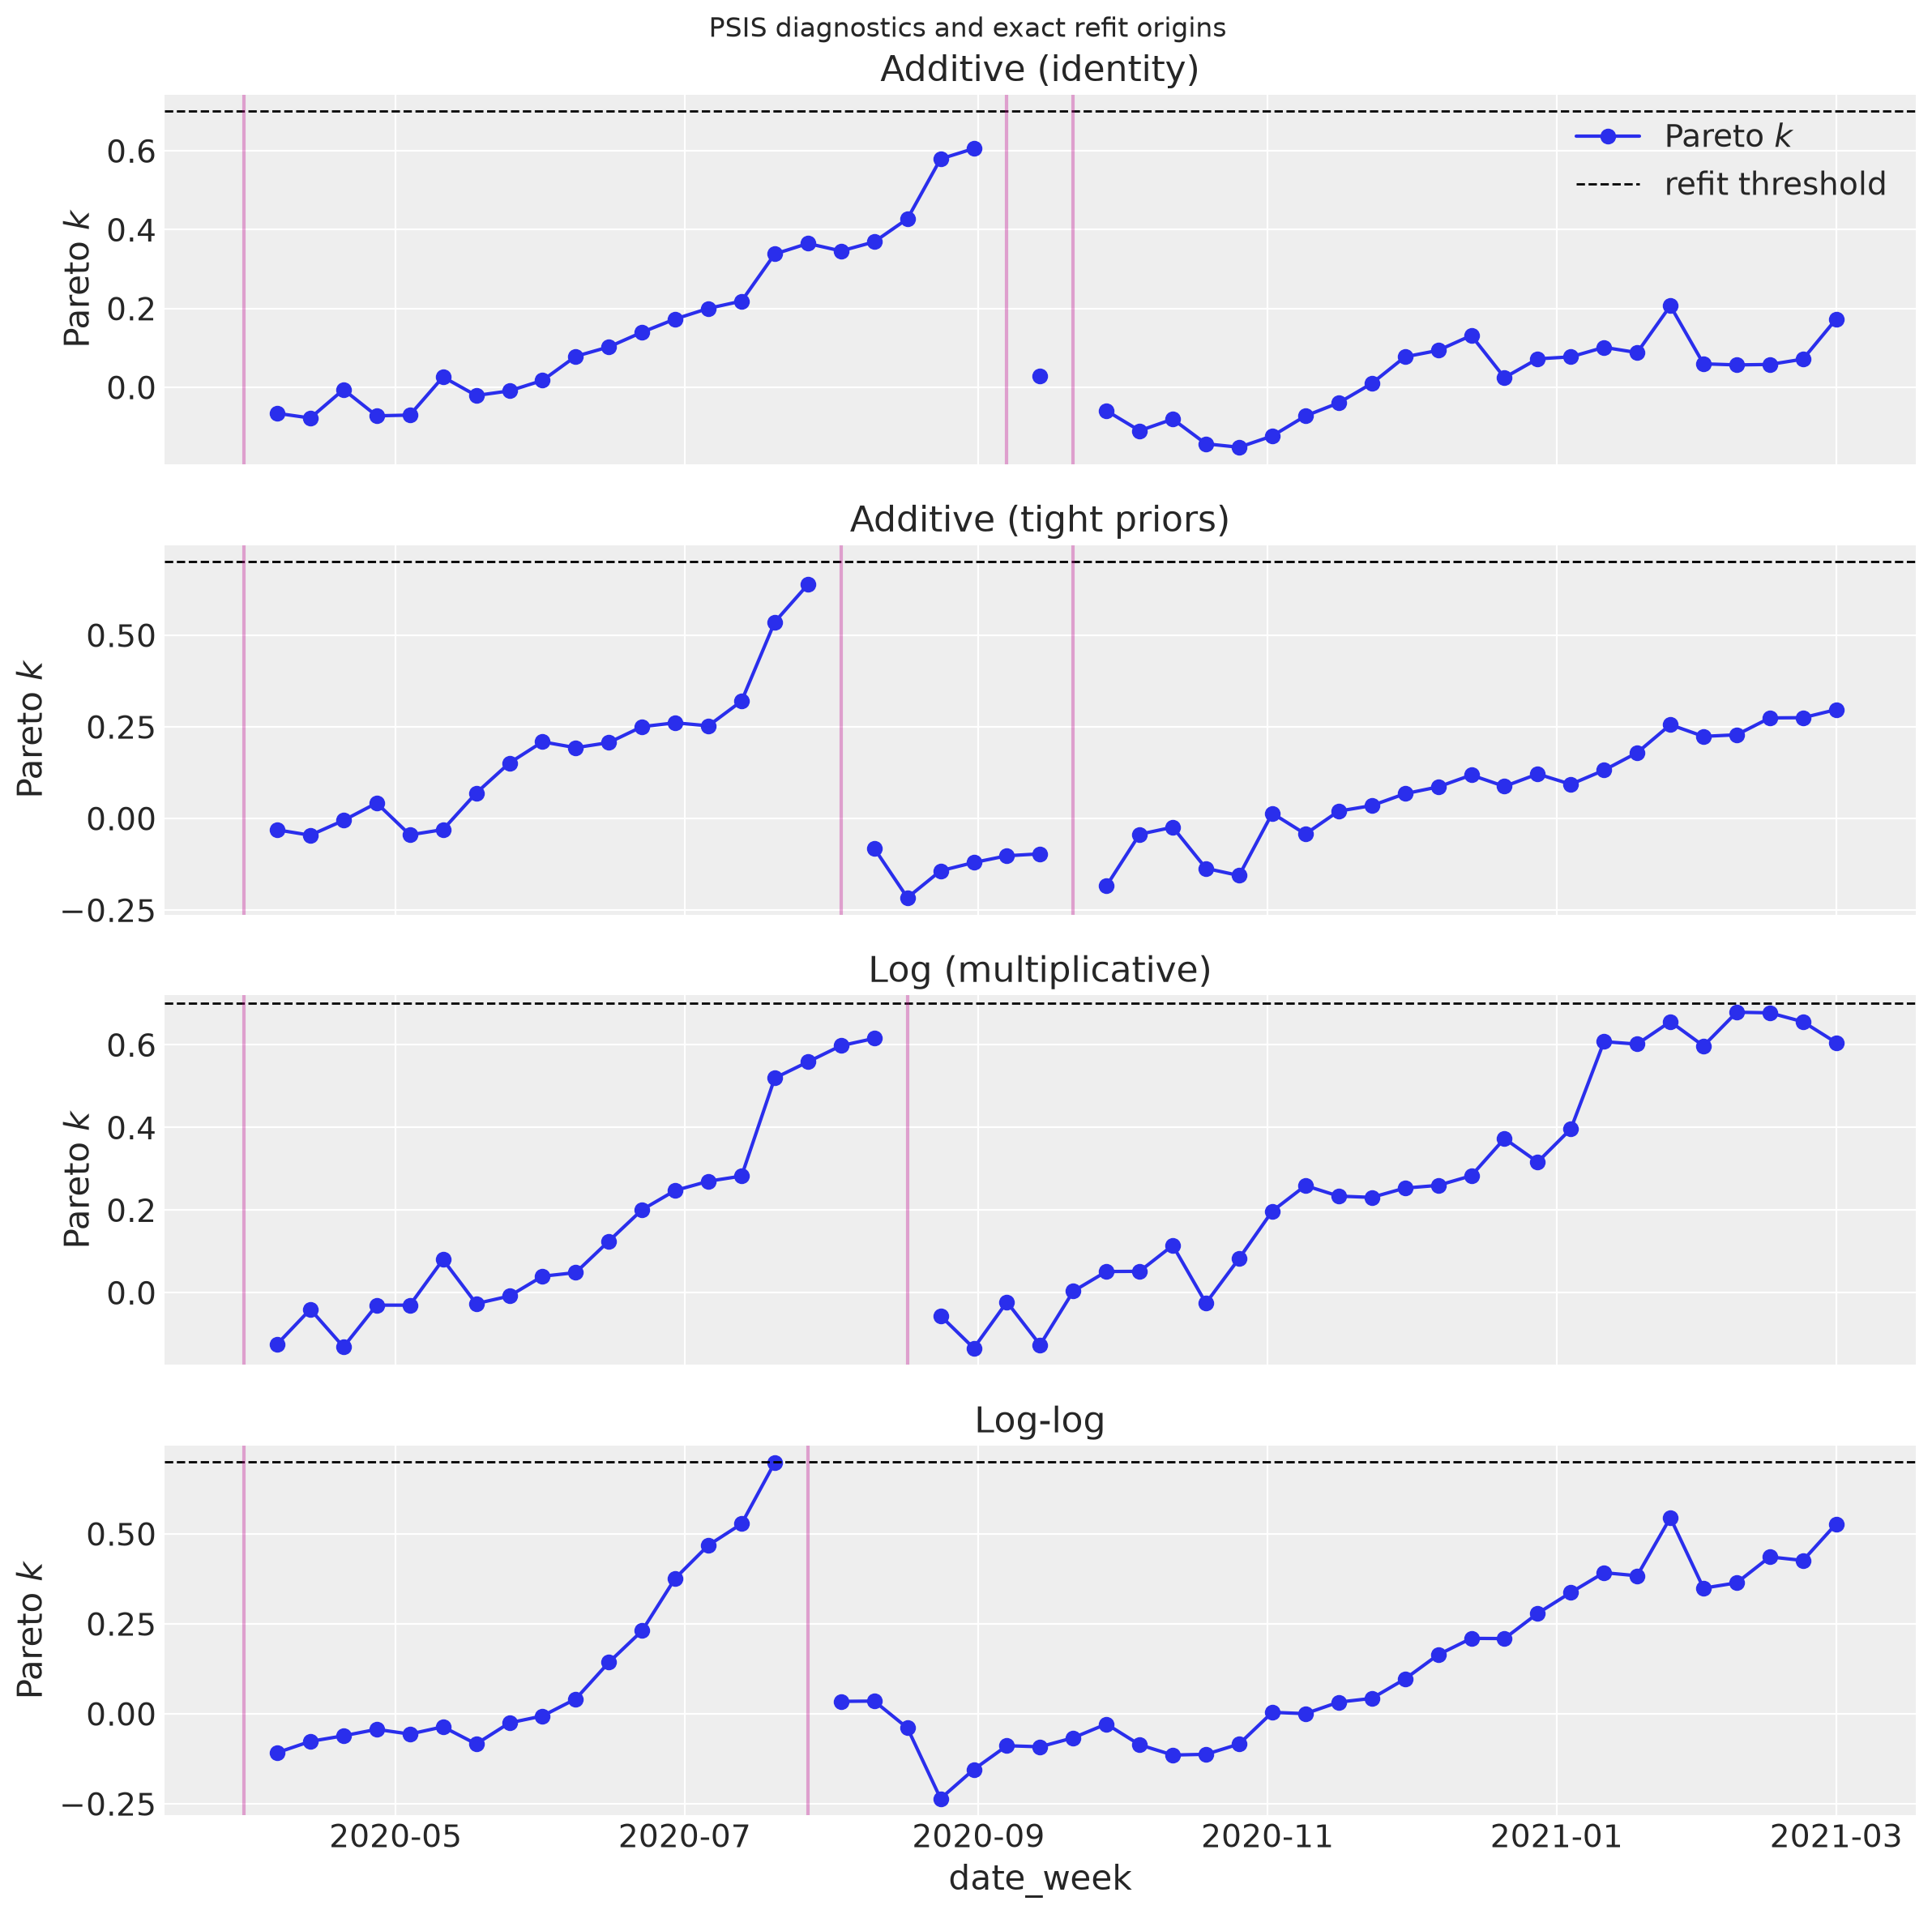

In [13]:
fig, axes = plt.subplots(
    len(MODEL_NAMES), 1, figsize=(12, 3 * len(MODEL_NAMES)), sharex=True
)
axes = np.atleast_1d(axes)
for axis, model_name in zip(axes, MODEL_NAMES, strict=True):
    result = lfo_results[model_name]
    dates = result.elpd_i.coords["date"].values
    if result.pareto_k is not None:
        axis.plot(dates, result.pareto_k.values, marker="o", label="Pareto $k$")
    axis.axhline(
        K_THRESHOLD, color="black", linestyle="--", linewidth=1, label="refit threshold"
    )
    refit_dates = pd.DataFrame(lfo_wrappers[model_name].refit_rows).get(
        "forecast_date", pd.Series(dtype="datetime64[ns]")
    )
    for refit_date in refit_dates.dropna():
        axis.axvline(refit_date, color="C3", alpha=0.35, linewidth=1.5)
    axis.set_ylabel("Pareto $k$")
    axis.set_title(MODEL_LABELS[model_name])
axes[-1].set_xlabel(DATE_COLUMN)
axes[0].legend(loc="upper right")
fig.suptitle("PSIS diagnostics and exact refit origins")
fig.tight_layout()

## Holdout check with pre-holdout stacking weights

The LFO-CV comparison above uses only the pre-holdout history. As a final check, we reserve the last `HOLDOUT_WEEKS` observations, estimate stacking weights from the pre-holdout LFO scores, and evaluate both the individual models and the stacked predictive mixture on that untouched future period.

The holdout scores are computed on the same scaled target used internally by the likelihood, so they are on the same scale as the LFO log scores. This holdout is not used to choose the model or estimate weights; it is a transparent out-of-sample check of the decision suggested by LFO-CV. Because the holdout has only 26 weeks, we read it together with the paired LFO standard errors rather than treating it as a definitive re-ranking.

In [14]:
def holdout_predictions(mmm, holdout_data: pd.DataFrame) -> xr.DataTree:
    """Sample posterior predictions for the holdout on the model's scaled target."""
    x_holdout = holdout_data.drop(columns=[TARGET_COLUMN])
    posterior_predictive = mmm.sample_posterior_predictive(
        X=x_holdout,
        extend_idata=False,
        combined=False,
        include_last_observations=True,
        random_seed=SEED,
        progressbar=False,
    )
    samples = posterior_predictive[mmm.output_var]
    if samples.sizes["date"] != len(holdout_data):
        raise ValueError("Unexpected posterior predictive holdout length.")
    observed_scaled = holdout_data[TARGET_COLUMN].to_numpy() / float(
        mmm.scalers["_target"].item()
    )
    return xr.DataTree.from_dict(
        {
            "/posterior_predictive": xr.DataTree(
                samples.to_dataset(name=TARGET_COLUMN)
            ),
            "/observed_data": xr.DataTree(
                xr.Dataset(
                    {TARGET_COLUMN: ("date", observed_scaled)},
                    coords={"date": holdout_data[DATE_COLUMN].to_numpy()},
                )
            ),
        }
    )


def holdout_log_likelihood(mmm, idata, holdout_data: pd.DataFrame):
    """Compute exact pointwise holdout log likelihood on the scaled target."""
    x_holdout = holdout_data.drop(columns=[TARGET_COLUMN])
    y_holdout = holdout_data[TARGET_COLUMN]
    dataset_xarray = mmm._posterior_predictive_data_transformation(
        X=x_holdout,
        y=y_holdout,
        include_last_observations=True,
    )
    model = mmm.model.copy()
    model = mmm._set_xarray_data(dataset_xarray=dataset_xarray, model=model)
    for mu_effect in mmm.mu_effects:
        mu_effect.set_data(mmm, model, dataset_xarray)

    idata_for_ll = idata.copy()
    if "log_likelihood" in idata_for_ll:
        del idata_for_ll["log_likelihood"]
    pm.compute_log_likelihood(
        idata_for_ll,
        var_names=[mmm.output_var],
        model=model,
        progressbar=False,
    )
    log_lik = idata_for_ll["log_likelihood"][mmm.output_var]
    log_lik = log_lik.isel(date=slice(-len(holdout_data), None))
    return log_lik.assign_coords(date=holdout_data[DATE_COLUMN].to_numpy())


def log_mean_exp(log_values, axis=-1):
    """Compute log(mean(exp(log_values))) stably."""
    return sp.logsumexp(log_values, axis=axis) - np.log(log_values.shape[axis])


cutoff = len(data) - HOLDOUT_WEEKS
holdout_data = data.iloc[cutoff:].copy()

pre_holdout_comparison = compare(lfo_results, method="stacking", round_to="none")
weights_by_name = pre_holdout_comparison["weight"].to_dict()

predictive_trees = {
    name: holdout_predictions(reference_mmm_by_model[name], holdout_data)
    for name in MODEL_NAMES
}
holdout_log_likelihoods = {
    name: holdout_log_likelihood(
        reference_mmm_by_model[name], reference_mmm_by_model[name].idata, holdout_data
    )
    for name in MODEL_NAMES
}

ordered_trees = [predictive_trees[name] for name in MODEL_NAMES]
weights = np.array([weights_by_name[name] for name in MODEL_NAMES], dtype=float)
stacked_tree = weight_predictions(
    ordered_trees,
    weights=weights,
    group="posterior_predictive",
    random_seed=SEED,
)

individual_lpd = {}
for name, log_lik in holdout_log_likelihoods.items():
    log_lik_by_sample = log_lik.stack(sample=("chain", "draw")).transpose(
        "date", "sample"
    )
    individual_lpd[name] = xr.DataArray(
        log_mean_exp(log_lik_by_sample.values, axis=1),
        dims=["date"],
        coords={"date": log_lik_by_sample.coords["date"].values},
    )

model_log_scores = np.vstack([individual_lpd[name].values for name in MODEL_NAMES])
stacked_log_score = sp.logsumexp(np.log(weights)[:, None] + model_log_scores, axis=0)

score_rows = []
for name in MODEL_NAMES:
    values_holdout = predictive_trees[name]["posterior_predictive"][
        TARGET_COLUMN
    ].values
    actual_scaled = predictive_trees[name]["observed_data"][TARGET_COLUMN].values
    for date, actual, log_score, samples in zip(
        holdout_data[DATE_COLUMN],
        actual_scaled,
        individual_lpd[name].values,
        values_holdout.transpose(2, 0, 1),
        strict=True,
    ):
        score_rows.append(
            {
                "model": MODEL_LABELS[name],
                "date": date,
                "actual_scaled": actual,
                "log_score": log_score,
                "crps": crps(actual, samples.flatten()),
            }
        )

stacked_values = stacked_tree["posterior_predictive"][TARGET_COLUMN].values
stacked_actual = predictive_trees[MODEL_NAMES[0]]["observed_data"][TARGET_COLUMN].values
for date, actual, log_score, samples in zip(
    holdout_data[DATE_COLUMN],
    stacked_actual,
    stacked_log_score,
    stacked_values,
    strict=True,
):
    score_rows.append(
        {
            "model": "Stacked",
            "date": date,
            "actual_scaled": actual,
            "log_score": log_score,
            "crps": crps(actual, samples.flatten()),
        }
    )

holdout_scores = pd.DataFrame(score_rows)
holdout_summary = (
    holdout_scores.groupby("model", sort=False)
    .agg(holdout_log_score=("log_score", "sum"), holdout_crps=("crps", "mean"))
    .sort_values("holdout_log_score", ascending=False)
)

,holdout_log_score,holdout_crps
model,,
Additive (identity),51.968155,0.018429
Stacked,50.838532,0.019343
Log-log,46.887006,0.021227
Log (multiplicative),46.646295,0.022155
Additive (tight priors),46.410369,0.021727


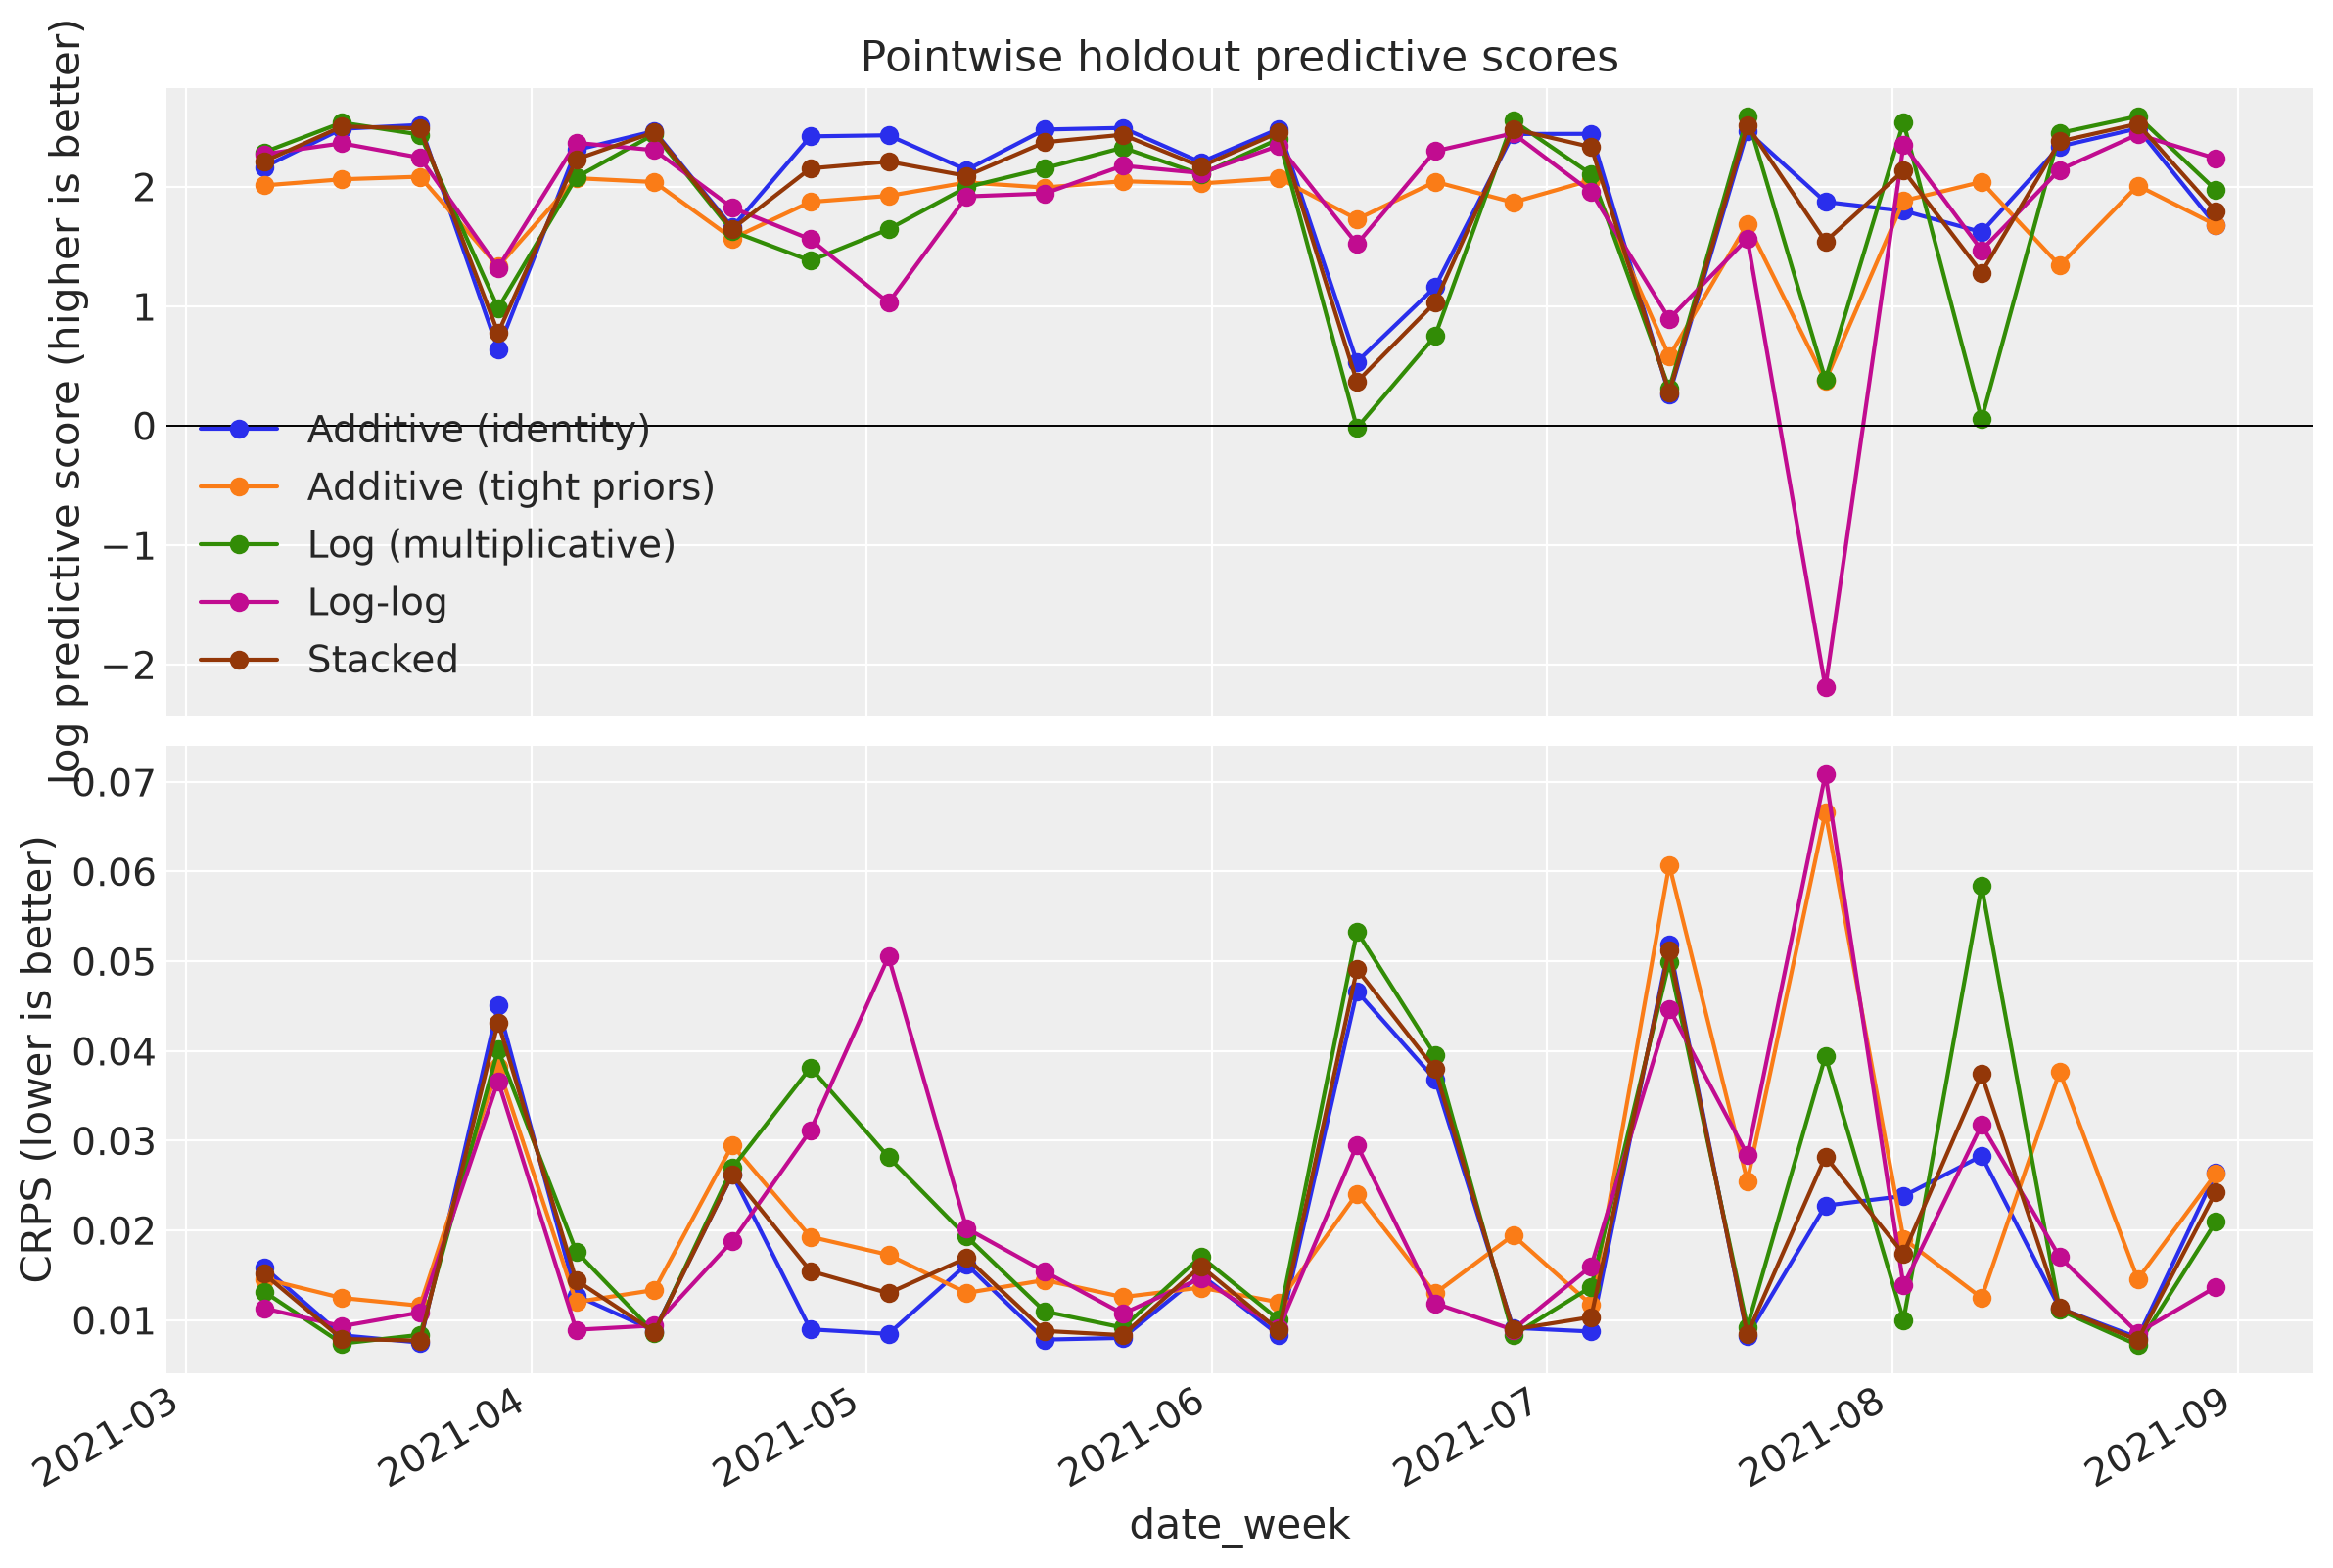

In [15]:
display(holdout_summary)

fig, (ax_log, ax_crps) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for model, group in holdout_scores.groupby("model", sort=False):
    ax_log.plot(group["date"], group["log_score"], marker="o", label=model)
    ax_crps.plot(group["date"], group["crps"], marker="o", label=model)
ax_log.axhline(0, color="black", linewidth=0.7)
ax_log.set_ylabel("log predictive score (higher is better)")
ax_log.set_title("Pointwise holdout predictive scores")
ax_crps.set_ylabel("CRPS (lower is better)")
ax_crps.set_xlabel(DATE_COLUMN)
ax_log.legend()
fig.autofmt_xdate()
fig.tight_layout()

## ROAS estimates across model assumptions

Predictive comparison tells us which model gives better future sales densities, but decision makers often also want to understand how the modeling assumptions affect business quantities such as return on ad spend (ROAS). The next plot compares in-sample all-time ROAS estimates for each candidate model and for the stacked predictive mixture.

These ROAS summaries should be read as model-implied quantities conditional on each specification. The stacked row is a weight-resampled mixture of model-implied ROAS distributions using prediction-optimal stacking weights; it is not a separate causal model and carries no claim of ROAS optimality. Under log-link models, unilateral channel increments are also not additive in the same way as in an identity-link model, so the ROAS comparison is best read as a sensitivity analysis across assumptions rather than proof of causal superiority.

In [16]:
def add_roas_to_predictions(mmm, idata):
    idata = idata.copy()
    roas = mmm.incrementality.compute_incremental_contribution(
        frequency="all_time"
    ) / mmm.idata["constant_data"]["channel_data"].sum("date")
    idata["posterior_predictive"] = idata["posterior_predictive"].assign(ROAS=roas)
    return idata


ordered_trees = [
    add_roas_to_predictions(reference_mmm_by_model[name], predictive_trees[name])
    for name in MODEL_NAMES
]
weights = np.array([weights_by_name[name] for name in MODEL_NAMES], dtype=float)
stacked_tree = weight_predictions(
    ordered_trees,
    weights=weights,
    group="posterior_predictive",
    random_seed=SEED,
)

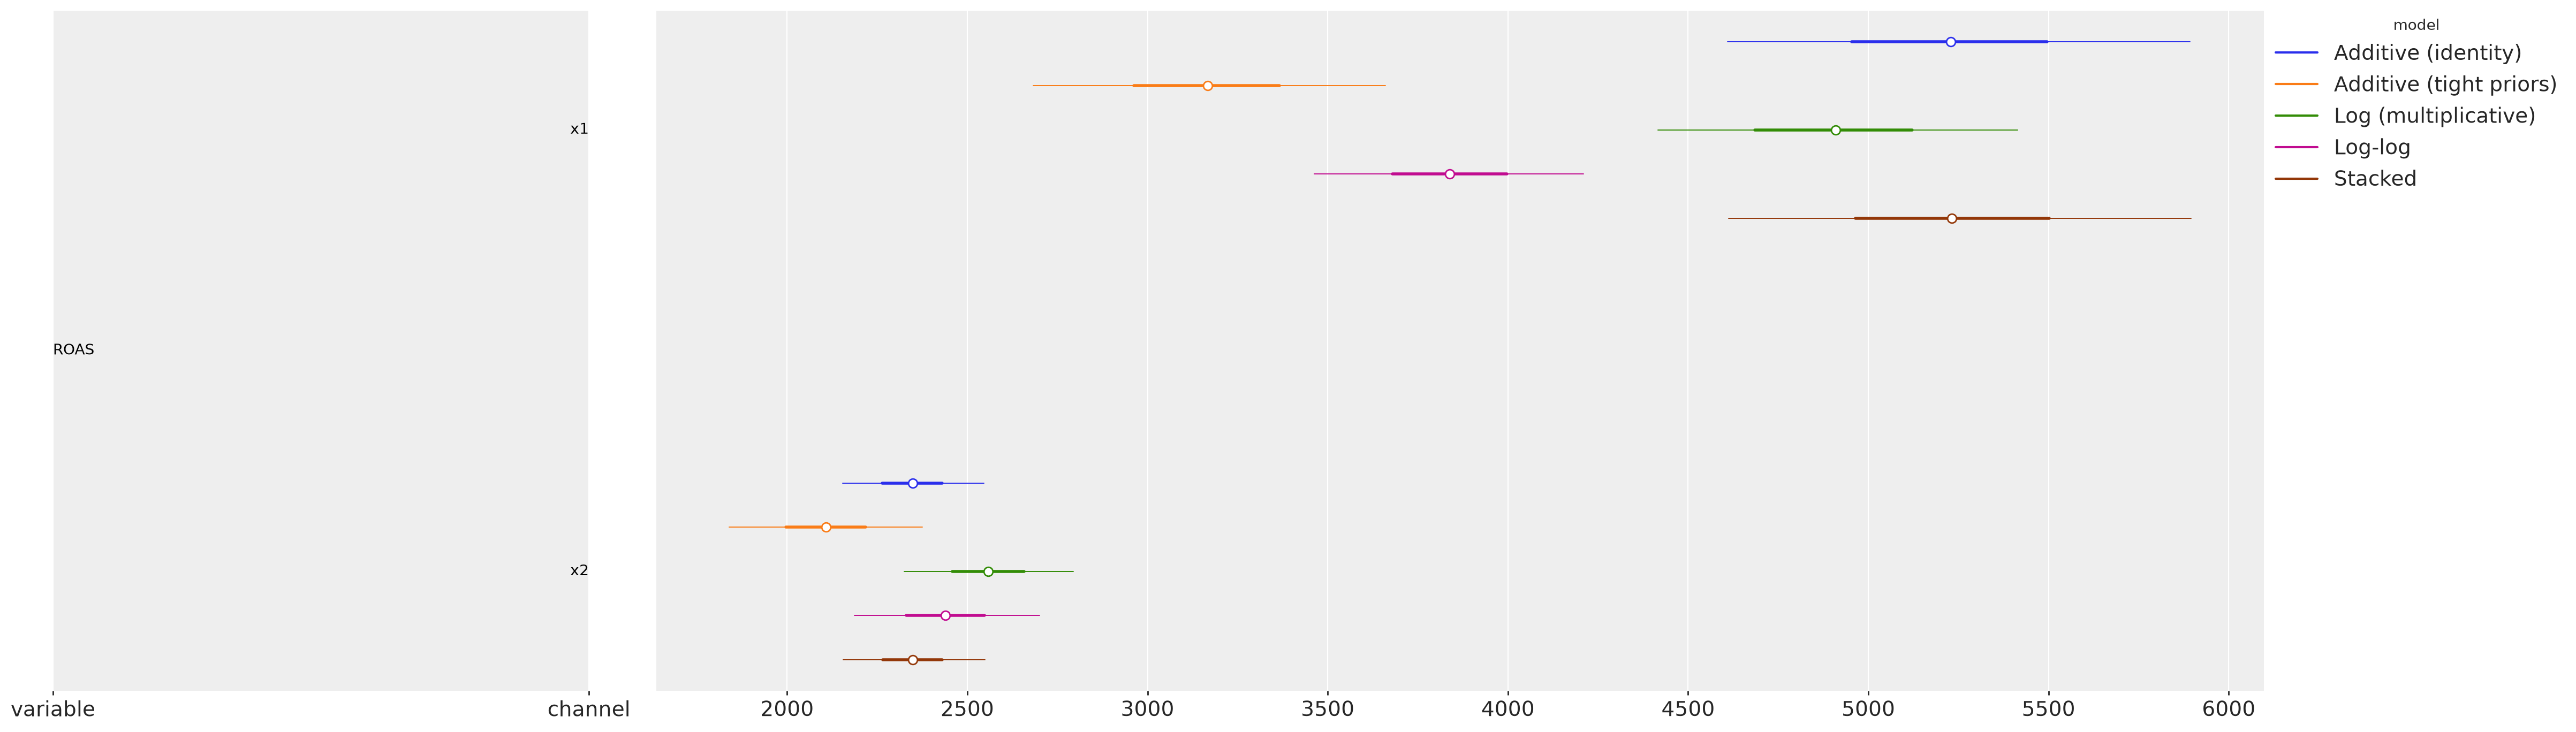

In [17]:
plot_num_samples = min(
    3999, stacked_tree["posterior_predictive"]["ROAS"].sizes["sample"]
)


def roas_tree_for_plot(tree, num_samples):
    roas_dataset = az.extract(
        tree,
        group="posterior_predictive",
        var_names=["ROAS"],
        keep_dataset=True,
        num_samples=num_samples,
    )["ROAS"].to_dataset(name="ROAS")
    roas_dataset = roas_dataset.assign_coords(
        sample=range(roas_dataset.sizes["sample"])
    )
    return xr.DataTree(children={"posterior_predictive": xr.DataTree(roas_dataset)})


def stacked_roas_tree_for_plot(tree, num_samples):
    roas = tree["posterior_predictive"]["ROAS"].isel(sample=slice(0, num_samples))
    roas_dataset = roas.to_dataset(name="ROAS").assign_coords(sample=range(num_samples))
    return xr.DataTree(children={"posterior_predictive": xr.DataTree(roas_dataset)})


roas_plot_trees = {
    **{
        MODEL_LABELS[name]: roas_tree_for_plot(tree, plot_num_samples)
        for name, tree in zip(MODEL_NAMES, ordered_trees, strict=True)
    },
    "Stacked": stacked_roas_tree_for_plot(stacked_tree, plot_num_samples),
}

pc = az.plot_forest(
    roas_plot_trees,
    var_names=["ROAS"],
    group="posterior_predictive",
    sample_dims=["sample"],
)
pc.add_legend(["model"])

## Takeaways

This case study uses LFO-CV to compare alternative MMM assumptions by the quantity we care about for forecasting: one-week-ahead predictive density for sales. The comparison is leakage-aware because every score is computed from models trained only on data available before the forecast origin, and the fixed scaling constants keep priors and parameters on a comparable scale across expanding-window refits.

The results illustrate three useful points:

- PSIS-LFO-CV can turn a rolling-origin Bayesian model comparison into a much smaller number of exact refits, while still reporting Pareto-$k$ diagnostics for the approximation.
- Single-model rankings should be read with their paired uncertainty. In this example, the holdout check is a noisy 26-week comparison and should be interpreted together with the LFO standard errors rather than as a definitive re-ranking.
- Stacking weights should be read as predictive-mixture weights. They can favor a lower-ranked individual model when that model contributes complementary predictions to the ensemble.

The ROAS comparison then shows how business-facing summaries can vary across plausible model assumptions. These summaries are model-implied sensitivity checks: they help us understand the implications of each specification, while the LFO-CV scores tell us which assumptions are more useful for predicting future sales in this dataset.

## References

- Bürkner, P.-C., Gabry, J., & Vehtari, A. (2020). [Approximate leave-future-out cross-validation for Bayesian time series models](https://www.tandfonline.com/doi/full/10.1080/00949655.2020.1783262). *Journal of Statistical Computation and Simulation*.
- Vehtari, A., Simpson, D., Gelman, A., Yao, Y., & Gabry, J. (2024). [Pareto smoothed importance sampling](https://jmlr.org/papers/v25/19-556.html). *Journal of Machine Learning Research*.
- PyMC-Marketing documentation: {ref}`mmm_multiplicative`.

In [18]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Fri, 18 Sep 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4

arviz         : 1.2.0
arviz_base    : 1.2.0
arviz_stats   : 1.4.0.dev0
logging       : 0.5.1.2
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
scipy         : 1.18.0
xarray        : 2026.4.0

Watermark: 2.6.0

